/home/jaya/synthetic-satellite
INFO 02-03 06:51:02 __init__.py:183] Automatically detected platform cuda.


INFO:src.core.memories.deepseek_image_rag:Initializing DeepSeek LLM...


WARNING 02-03 06:51:04 config.py:2368] Casting torch.bfloat16 to torch.float16.
INFO 02-03 06:51:12 config.py:526] This model supports multiple tasks: {'embed', 'reward', 'generate', 'classify', 'score'}. Defaulting to 'generate'.
WARNING 02-03 06:51:12 cuda.py:100] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used
WARNING 02-03 06:51:12 config.py:662] Async output processing is not supported on the current platform type cuda.
INFO 02-03 06:51:12 llm_engine.py:232] Initializing a V0 LLM engine (v0.7.1) with config: model='deepseek-ai/deepseek-coder-1.3b-base', speculative_config=None, tokenizer='deepseek-ai/deepseek-coder-1.3b-base', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=128, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, disable_

[W203 06:51:14.715183969 CUDAAllocatorConfig.h:28] Warning: expandable_segments not supported on this platform (function operator())


INFO 02-03 06:51:14 weight_utils.py:251] Using model weights format ['*.bin']


Loading pt checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


INFO 02-03 06:51:17 model_runner.py:1116] Loading model weights took 2.5237 GB
INFO 02-03 06:51:18 worker.py:266] Memory profiling takes 0.69 seconds
INFO 02-03 06:51:18 worker.py:266] the current vLLM instance can use total_gpu_memory (14.56GiB) x gpu_memory_utilization (0.30) = 4.37GiB
INFO 02-03 06:51:18 worker.py:266] model weights take 2.52GiB; non_torch_memory takes 0.03GiB; PyTorch activation peak memory takes 0.30GiB; the rest of the memory reserved for KV Cache is 1.52GiB.
INFO 02-03 06:51:19 executor_base.py:108] # CUDA blocks: 517, # CPU blocks: 1365
INFO 02-03 06:51:19 executor_base.py:113] Maximum concurrency for 128 tokens per request: 64.62x
INFO 02-03 06:51:22 llm_engine.py:429] init engine (profile, create kv cache, warmup model) took 5.06 seconds


INFO:src.core.memories.deepseek_image_rag:Initializing text embedding model...
/home/jaya/synthetic-satellite/src/core/memories/deepseek_image_rag.py:74: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  self.text_embedding_model = HuggingFaceEmbeddings(
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: BAAI/bge-large-en-v1.5
INFO:src.core.memories.deepseek_image_rag:Initializing image embedding model...


Setting up test data...


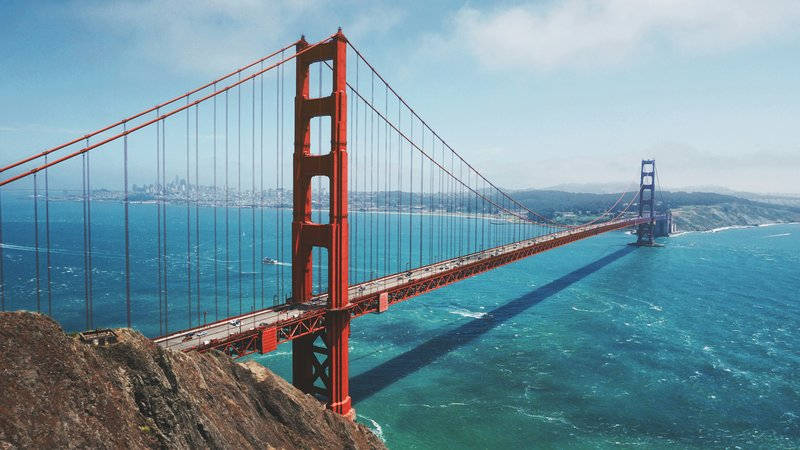

INFO:faiss.loader:Loading faiss with AVX2 support.


Downloaded: golden_gate.jpg - Golden Gate Bridge in San Francisco

Adding documents to RAG system...


INFO:faiss.loader:Successfully loaded faiss with AVX2 support.
INFO:src.core.memories.deepseek_image_rag:Added 1 textual documents to the vector store
ERROR:src.core.memories.deepseek_image_rag:Error adding images: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor
ERROR:__main__:Test failed: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor



Test environment cleaned up.


RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [5]:
import os
import sys
import json
import shutil
import tempfile
from PIL import Image
import numpy as np
import logging
from dotenv import load_dotenv
import requests
from io import BytesIO
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage, HTML
from typing import List, Dict, Any
import torch

# Load environment variables
load_dotenv()

load_dotenv()
project_root = os.getenv('PROJECT_ROOT')
sys.path.append(project_root)
print(project_root)
# Import DeepSeekImageRAG
from src.core.memories.deepseek_image_rag import DeepSeekImageRAG


class TestDeepSeekImageRAG:
    def __init__(self):
        """Initialize the test environment"""
        self.temp_dir = tempfile.mkdtemp()
        self.test_data_dir = os.path.join(self.temp_dir, 'test_data')
        os.makedirs(self.test_data_dir, exist_ok=True)
        
        try:
            # Initialize RAG system with reduced memory usage
            self.rag = DeepSeekImageRAG(
                model_name="deepseek-ai/deepseek-coder-1.3b-base",
                embedding_model="BAAI/bge-large-en-v1.5",
                image_embedding_model="openai/clip-vit-base-patch32",
                max_tokens=256,  # Reduce sequence length
                temperature=0.7,
                top_k_docs=1,  # Reduce number of retrieved documents
                verbose=True
            )
        except Exception as e:
            logger.error(f"Failed to initialize RAG system: {str(e)}")
            self.cleanup()
            raise

    def download_image(self, url: str, filename: str) -> str:
        """Download image from URL and save to directory"""
        try:
            response = requests.get(url, timeout=10)
            response.raise_for_status()
            img = Image.open(BytesIO(response.content))
            
            # Resize image to reduce memory usage
            max_size = (800, 800)
            img.thumbnail(max_size, Image.Resampling.LANCZOS)
            
            path = os.path.join(self.test_data_dir, filename)
            img.save(path, optimize=True, quality=85)
            return path
        except Exception as e:
            logger.warning(f"Failed to download image {url}: {str(e)}")
            # Create a smaller fallback image
            img = Image.new('RGB', (100, 100), (255, 0, 0))
            path = os.path.join(self.test_data_dir, filename)
            img.save(path)
            return path

    def setup_test_data(self):
        """Set up test data including images and knowledge bases"""
        # Image data with URLs and descriptions
        image_data = {
            'golden_gate.jpg': {
                'url': 'https://images.unsplash.com/photo-1501594907352-04cda38ebc29',
                'description': 'Golden Gate Bridge in San Francisco',
                'fallback_color': (218, 165, 32)
            }
        }
        
        # Download images
        image_paths = {}
        for filename, data in image_data.items():
            path = self.download_image(data['url'], filename)
            image_paths[filename] = path
            
            # Display downloaded images
            display(IPImage(filename=path, width=300))
            print(f"Downloaded: {filename} - {data['description']}")
        
        # Create minimal text knowledge base
        text_documents = [
            {
                "content": "The Golden Gate Bridge is an iconic suspension bridge spanning the Golden Gate strait. "
                          "It connects San Francisco to Marin County and is known for its distinctive orange color.",
                "metadata": {"type": "landmark", "subject": "Golden Gate Bridge"}
            }
        ]
        
        # Create image documents
        image_documents = [
            {
                "path": image_paths['golden_gate.jpg'],
                "metadata": {
                    "type": "landmark",
                    "subject": "Golden Gate Bridge",
                    "description": "Iconic orange suspension bridge in San Francisco"
                }
            }
        ]
        
        return text_documents, image_documents

    def run_test_queries(self):
        """Run test queries and display results"""
        test_queries = [
            "What can you tell me about the Golden Gate Bridge?"
        ]
        
        for query in test_queries:
            print(f"\n\nQuery: {query}")
            print("-" * 50)
            
            try:
                # Get results
                results = self.rag.search(query)
                
                # Display relevant images
                plt.figure(figsize=(10, 5))
                for i, img_result in enumerate(results['images'][:1]):
                    img_path = img_result['metadata']['path']
                    plt.subplot(1, 1, i+1)
                    plt.imshow(Image.open(img_path))
                    plt.title(f"Relevant Image {i+1}")
                    plt.axis('off')
                plt.show()
                
                # Generate and display answer
                answer = self.rag.generate_answer(query)
                print("\nGenerated Answer:")
                print(answer)
                
                # Display relevant text snippets
                print("\nRelevant Text Snippets:")
                for i, text_result in enumerate(results['texts'][:1]):
                    print(f"\n{i+1}. {text_result['document'][:200]}...")
                    
            except Exception as e:
                logger.error(f"Error processing query '{query}': {str(e)}")
                continue

    def cleanup(self):
        """Clean up temporary files"""
        try:
            shutil.rmtree(self.temp_dir)
            print("\nTest environment cleaned up.")
            
            # Clear CUDA cache
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                
        except Exception as e:
            logger.error(f"Error during cleanup: {str(e)}")

def run_notebook_test():
    """Run the complete test in notebook"""
    test = None
    try:
        # Initialize test environment
        test = TestDeepSeekImageRAG()
        
        # Set up test data
        print("Setting up test data...")
        text_docs, image_docs = test.setup_test_data()
        
        # Add documents to RAG system
        print("\nAdding documents to RAG system...")
        test.rag.add_text_documents(text_docs)
        test.rag.add_images(image_docs)
        
        # Run test queries
        print("\nRunning test queries...")
        test.run_test_queries()
        
    except Exception as e:
        logger.error(f"Test failed: {str(e)}")
        raise
    
    finally:
        # Cleanup
        if test is not None:
            test.cleanup()

# Run the test
if __name__ == "__main__":
    run_notebook_test()